In [2]:
from dotenv import load_dotenv

load_dotenv("c:/WIP/deep-research-lab/.env")

True

In [3]:
import sys
sys.path.append("c:/WIP/deep-research-lab")

from IPython.display import Image, display, Markdown
from multi_agent import supervisor_builder
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
agent = supervisor_builder.compile(checkpointer=memory)

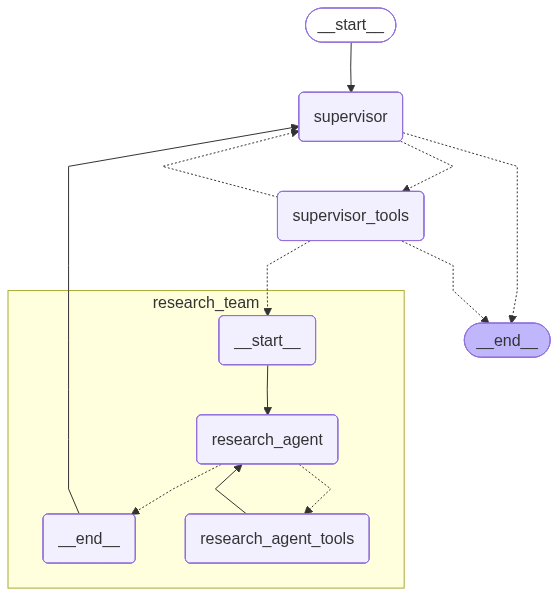

In [4]:
display(Image(agent.get_graph(xray=1).draw_mermaid_png(max_retries=5)))

In [5]:
from IPython.display import display, Markdown
from rich import print
import uuid 

thread = {"configurable": {
                            "thread_id": str(uuid.uuid4()), #  Checkpoint를 위한 고유 스레드 ID 생성
                           "search_api": "tavily",
                           }}

user = [{"role": "user", "content": "2026년 근로기준법에 어떤 변화가 있는지 조사하고 이전과 어떤것이 달라졌는지 상세히 설명해줘"}]

# async for event in agent.astream({"messages":user}, thread, stream_mode="updates"):
#     node_name, message_chunk = event
    
#     # LLM 응답 실시간 출력
#     print(message_chunk)

response = await agent.ainvoke({"messages": user}, config=thread)

In [6]:
display(Markdown(agent.get_state(thread).values['final_report']))

# 근로기준법(2026) 개정 주요 변경사항 보고서

본 보고서는 2026년을 기점으로 시행되거나 예정된 근로기준법 관련 주요 개정사항을 정리하고, 개정 전·후의 차이점을 실무 관점에서 비교·분석하기 위해 작성되었습니다. 대상 독자는 사업주(인사·노무 담당자), 근로자 및 노조, 노무사·법률가, 정책담당자 등으로, 법령·행정해석·대법원 판결·고용노동부 보도자료와 주요 법률해설을 근거로 핵심 쟁점을 도출하였습니다.

보고서의 범위와 구성
- 범위: 근로시간·연장근로 규정, 휴가·휴직(출산·육아·가족돌봄), 임금 및 지급방식(임금명세서·최저임금 산입기준), 비정규직·파견·플랫폼노동자 보호, 해고·퇴직·징계 및 사후구제, 감독·벌칙·시행·유예 조치, 현장 영향 및 대응 방안 등 주요 영역.
- 방법론: 고용노동부 보도자료, 법령(법·시행령·시행규칙), 대법원 판결문, 전문 법률사례·해설자료를 교차검증하여 개정의 내용·시행시기·적용범위·실무적 영향으로 분류·정리.

중심 요지(요약)
- 임금체불·징벌적 제재 강화, 노동시간 규제·기록 의무화, 적용범위의 확대(특수고용직·플랫폼·5인 미만 사업장 단계적 포함), 육아·안전 관련 지원·특례 도입 및 포괄임금제·연장근로 해석 변화가 핵심적 변화입니다.
- 대법원 판결에 따른 연장근로 판단기준 변경, 육아휴직 급여·사용기간 확대, 임금명세서·최저임금 산입기준 명확화 등은 사업장 운영·인사노무 관리에 즉각적·가시적 영향을 미칩니다.

보고서 읽는 방법
- 본문(제공된 ‘메인바디 섹션’)은 각 영역별로 개정 전후 차이와 실무적 시사점을 정리한 내용입니다. 이 서론은 보고서 목적·범위·핵심요지를 제시하며, 결론 부분에서는 실무적 권고와 우선 대응 과제를 요약합니다.

## 요약 및 핵심 변경사항

- 개요: 고용노동부 보도자료·법령전문·해설자료를 종합해 주요 개정사항을 정리함. 핵심 내용은 임금체불 제재 강화, 노동시간 규제·기록 의무화, 적용범위 확대(특고·플랫폼·5인 미만 포함), AI·육아·안전 관련 특례 도입 등이다.

- 주요 변경점:
  - 임금체불 강화: 1년간 3개월분 이상 또는 5회·총액 3천만원 기준의 상습체불 지정 → 명단공개·신용제재·정부지원 제한·출국금지·지연이자 확대·징벌적 손해배상(최대 3배).
  - 노동시간·포괄임금: 포괄임금 금지 검토, 노동시간 기록·실노동시간 단축 로드맵(목표 OECD 수준·주4.5일 시범).
  - 적용범위·시행시기: 5인 미만 단계적 확대, ‘노동자 추정제’ 도입 검토, 고용보험 가입기준을 시간→소득 전환(예: 10시 출근제 ’26.1월, 단기 육아휴직 ’26.7월 등).

### Sources
1. https://www.moel.go.kr/news/enews/report/enewsView.do?news_seq=18725
2. https://lawform.io/magazine/877
3. https://thecodit.com/kr-ko/bill/sh/20251223-000000002215512

## 근로시간·연장근로 규정의 변화

요약:
- 핵심 판단 변경: 대법원(2023.12.7, 2020도15393)은 연장근로 한도 위반 여부를 ‘1주 총근로시간 중 40시간 초과분’으로 판단해야 한다고 판시. 이에 고용노동부는 2024.1.22 행정해석을 변경하여 동일 기준을 적용한다고 발표.

주요 내용:
- 계산기준 변화로 1일별 8시간 초과분을 단순 합산하던 종전 관행과 차이 발생(형사책임 판단 기준 변경).
- 연장근로 수당 지급 기준(일·주 기준의 가산임금 지급)은 종전과 동일하게 유지됨(1일·1주 초과분 가산).
- 선택적·탄력적 근로시간제 관련: 제도 자체의 적용요건·주·월 단위 규정은 변하지 않으나, 연장근로 한도 판단에서 주단위 총근로시간 기준이 재확인되어 제도 운영상 해석이 달라질 수 있음.

영향·논점:
- 사용자 형사책임 부담 축소 가능성, 노동계의 건강권 우려, 입법(일별 한도 명문화) 논의 지속.

### Sources
1. https://www.moel.go.kr/news/enews/report/enewsView.do?news_seq=16103
2. https://www.kimchang.com/ko/insights/detail.kc?sch_section=4&idx=28823
3. https://sooholabor.co.kr/kwa-2157-16?PB_1697096211=3&pc=p

## 휴가·휴일·휴직 규정의 변화

최근 개정은 연차·출산·육아 관련 수급범위 확대와 급여지급 방식 변경에 중점.

- 연차유급휴가: 근로기준법 제60조 개정으로 육아휴직·임신기·육아기 단축근로 등이 ‘출근’으로 산정(2024.10.22 개정사항).
- 출산휴가·유급휴일: 미숙아 휴가 기간 확대(90→100일), 배우자 출산휴가 확대(10→20일), 유산·사산휴가 연장 등과 함께 출산휴가와 육아휴직의 통합신청 허용.
- 육아휴직·육아기 단축: 육아휴직 급여 대폭 인상·사후지급 폐지→휴직기간 중 전액 지급, 부모별 사용기간(1→1.5년), 분할·상한 조정(예: 초기 상한 1~3개월 250만원 등), 육아기 근로시간 단축 대상 연령 만12세로 확대.
- 대체인력 지원: 중소기업 지원금 상향(월 80→120만원 등).

가족돌봄휴가 관련 세부 수급·급여 조정은 고용노동부 공지 및 시행령 검토 필요.

### Sources
1. https://shiftee.io/ko/blog/article/2025-parental-leave-policy-changes-summary
2. https://www.law.go.kr/LSW//lsSideInfoP.do?lsiSeq=265959&joNo=0060&joBrNo=00&docCls=jo&urlMode=lsScJoRltInfoR
3. https://www.jipyong.com/kr/board/news_view.php?seq=13758&page=15&value=&type=&nownum=130

## 임금·최저임금·임금지급 방식의 변화

조사 요약:
- 최저임금 산입기준: 고용노동부는 ‘매월 1회 이상 정기적으로 지급되는 임금’을 최저임금 산입 대상으로 명확화하고, 통화 외 지급액의 월 환산 방법 등을 규정함.
- 지급 주기·기한: 근로기준법상 임금은 ‘매월 1회 이상 일정한 날짜’를 정하여 지급해야 함(제43조).
- 임금명세서 의무화(시행 2021.11.19): 임금의 구성항목·계산방법·공제내역 등을 서면(전자문서 포함)으로 교부해야 하며, 미교부·허위 기재 시 과태료 부과 등 제재가 있음.

주요 차이점:
- 종전에는 산입범위·명세서 규정 일부가 시행령·시행규칙에 의존했으나, 개정으로 법·시행령 차원에서 산입기준 명확화·명세서 교부 의무화 및 제재 강화가 이루어짐.

### Sources
1. https://www.moel.go.kr/policy/policydata/view.do?bbs_seq=20180600351
2. https://www.law.go.kr/LSW/lsInfoP.do?lsiSeq=236819
3. https://blog.naver.com/timeword2/222533504831

## 비정규직·파견·플랫폼노동자 보호 강화

비정규직(기간제), 파견, 플랫폼 노동자의 보호를 위해 판결·행정자료·정책권고를 종합 정리함.

- 근로자성 판단: 대법원·학계 판례는 플랫폼 작업자의 종속성·지휘·보수구조 등 실제 근로관계를 중심으로 근로자성 인정 가능성을 제시함(판례·학술 분석). 
- 행정·정책적 근거: 고용노동부는 파견·기간제 등 비정규직 보호를 위한 기본계획·운영권한을 보유하며 행정해석을 통해 적용범위를 조정함.
- 제도개선 권고(주요 쟁점): 플랫폼에 대한 근로감독 기준 명확화, 사회보험·산재·퇴직금 적용 확대, 계약·알고리즘 통제 여부를 근로자성 판단에 반영, 파견·기간제 사용 제한 강화.

정책 제언: 근로자성 판단의 실체적 기준을 행정지침으로 명문화하고, 플랫폼 특성에 맞는 안전·사회안전망과 공정계약 규정을 법·행정으로 보완할 것.

### Sources
1. https://www.kci.go.kr/kciportal/ci/sereArticleSearch/ciSereArtiView.kci?sereArticleSearchBean.artiId=ART003127599
2. https://www.law.go.kr/LSW/flDownload.do?flSeq=151391775&flNm=%5B%EB%B3%84%ED%91%9C+1%5D+%EA%B3%A0%EC%9A%A9%EB%85%B8%EB%8F%99%EB%B6%80+%EB%B3%B8%EB%B6%80%EC%9D%98+%EC%9C%84%EC%9E%84%EC%A0%84%EA%B2%B0%EC%82%AC%ED%95%AD%28%EC%A0%9C12%EC%A1%B0+%EA%B4%80%EB%A0%A8%29
3. http://iwr.or.kr/?module=file&act=procFileDownload&file_srl=492&sid=02021f930b781887f87a9dcb38cd0e6a&module_srl=135

## [해고·퇴직·징계 규정 및 사후구제]

핵심 발견(요약):
- 해고: 판례·법은 여전히 ‘정당한 이유’와 절차적 정당성(소명·소명기회·해고회피 노력)을 핵심으로 삼음; 행정지침(직무능력·성과 가이드북)은 저성과자 통상해고·평가기준 명문화로 해석되어 노사 갈등 유발 우려(전문가 비판).
- 퇴직금: 확정기여형 전환·중간정산시 산정·소멸시효와 부담금 기산일 등 법원 판례가 구체적 기준 제시(중간정산일·퇴직일 기준 판단). 
- 취업규칙·징계: 대법원은 ‘사회통념상 합리성’ 요건을 엄격히 판단, 집단적 동의 원칙 유지 필요성을 강조.
- 사후구제: 부당해고 구제는 노동위원회(중앙·지방)·행정구제·민사소송 병행, 최근 판례·행정지침 충돌 사례 다수.

정책적 시사점:
- 가이드라인은 법·판례와 조화시킬 구체적 절차·증거기준 필요.

### Sources
1. http://file.ltoss.co.kr/updata/newout/upload/185/160118095845000001989/%EC%9D%B4%EC%9D%8...160112.pdf
2. https://file.scourt.go.kr/dcboard/1689149426751_171026.pdf
3. https://blog.naver.com/hellopolicy/220609227845

## 감독·벌칙·시행·유예 조치

중앙부처의 법·행정규칙 개정 시 확인해야 할 핵심 항목과 출처 확인 방법을 요약한다.

- 시행시기: 법령별로 ‘공포 즉시’ 또는 ‘공포 후 일정 기간(시행유예)’ 규정. 시행조문을 우선 확인.
- 경과조치: 대체로 "종전 규정에 따른다"는 경과규정이 존재하며, 시행 전 행위에 대한 적용범위를 명시(위치정보법 시행령 등).
- 과태료·벌칙 강화: 과태료 상향·신설은 법령·시행령·별표 개정 필요. 원자력안전위원회 사례처럼 과태료 기준은 별도 규정으로 표시됨.
- 행정지도 지침 변동: 중앙부처는 행정예고·훈령·고시·공문으로 지침 변경을 통보하므로, 해당 부처 고시·훈령 및 법제처 국가법령정보센터의 공문·행정예고를 확인할 것.

권고: 적용 대상 부처의 시행령·훈령·고시 원문과 부처 공문(행정예고)을 우선 조회하여 경과조치·벌칙 조항을 비교 검토.

### Sources
1. https://www.nssc.go.kr/ajaxfile/FR_SVC/FileDown.do?GBN=X01&BOARD_SEQ=14&SITE_NO=2&BBS_SEQ=45979&FILE_SEQ=1
2. https://www.law.go.kr/LSW/lsInfoP.do?lsiSeq=277567
3. https://www.law.go.kr/LSW/admRulLsInfoP.do?admRulSeq=2100000268066

## 현장 영향 및 대응 방안(사업주·노동자 관점)

- 핵심 사실
  - 임금은 원칙적으로 근로자에게 통화로 직접 전액 지급(근로기준법 제43조). 제3자 수령은 엄격히 제한됨(대법원 판례).
  - 근로계약서는 서면 교부 의무(고용노동부)이며 미교부 시 처벌 가능.

- 사업주(권고)
  - 근로계약서·임금지급 방식·근태 규정은 서면·전자문서로 명확화하고, 변경 시 개별·단체 동의 확보.
  - 임금은 개별 계좌 직접이체(현금 시 수령 확인)로 전환; 소개인·중간수령 배제.
  - PMI·구조조정 시 사전 협의·집단 동의 절차 수립 및 퇴직금·근로조건 정산 프로세스 마련.

- 근로자(권고)
  - 계약서·임금지급방식·근태기록 사본 확보, 의심 시 고용노동부 상담·증거 보전.

- 예상 쟁점 및 권고
  - 임금 위임 무효, 불법파견·사용자 변경, 징계절차 적법성 등 분쟁 예상: 서면·시스템 기록으로 방어·예방.

### Sources
1. https://ihcf.or.kr/uploaded/board/newsletter_apply/_27a28177485c000967274155e82025f40.pdf
2. https://www.moel.go.kr/mainpop2.do
3. https://casenote.kr/%EB%B2%95%EB%A0%B9/%EA%B7%BC%EB%A1%9C%EA%B8%B0%EC%A4%80%EB%B2%95/%EC%A0%9C43%EC%A1%B0

## 결론

요약(핵심 정리)
- 2026년 근로기준법 개정은 노동시간·임금·휴가·비정규직 보호·감독 체계 등 노동관계 전반에 걸친 실질적 강화와 명확화를 목표로 한다. 특히 연장근로 규정의 해석·기록 의무화, 임금명세서·최저임금 산입기준 정비, 플랫폼·특수고용형태 노동자에 대한 적용확대 및 처벌·과태료 강화가 핵심 변화다.
- 일부 규정은 단계적(유예·경과) 적용되며, 대법원 판례 및 행정해석의 영향으로 실무상 판단기준(예: 연장근로, 근로자성)도 달라져 기업·근로자 모두의 준비가 요구된다.

실무적 시사점 및 권고
- 인사·노무 관리 시스템(근태·임금·근로계약서) 점검: 근로시간 기록·연장근로 승인 절차를 문서화하고 전자·종이 기록을 보존하라.
- 임금 체계 재검토: 포괄임금제 적용 여부, 최저임금 산입 항목, 임금명세서의 상세 기재(기본급·수당·연장근로·휴일수당 등)를 확인·수정하라.
- 비정규·플랫폼 노동자 대응: 기간제·파견계약 갱신정책, 플랫폼 노동자에 대한 근로자성 판단 및 계약형태 변경 가능성에 대비하라.
- 휴가·휴직 운영체계 정비: 연차·육아휴직 등 청구·급여지급 절차를 표준화하고 대체인력·업무분장 계획을 수립하라.
- 법적 리스크 관리: 징벌적 과태료·벌칙 강화에 대비하여 외부 노무·법률 자문을 확보하고, 노동감독·고용노동부 행정지도를 모니터링하라.

우선 대응 과제(단기 우선순위)
1. 근로계약서와 취업규칙(근로시간·임금·휴가 규정) 즉시 점검 및 필요시 수정
2. 근태관리 시스템(전자출퇴근·연장승인) 도입 또는 강화
3. 급여명세서 양식 개선 및 급여 산식 검증
4. 플랫폼·파견·기간제 노동자 현황 파악 및 계약관계 문서화
5. 노사 소통 계획 수립(개정 내용 설명·FAQ 제공)

향후 관찰 포인트
- 시행령·시행규칙과 고용노동부의 행정해석(지침)에서 세부 기준이 추가로 발표될 가능성이 높아, 세부 지침을 지속적으로 모니터링해야 한다.
- 대법원·하급심 판례의 변화가 실무 적용에 큰 영향을 미치므로 관련 판례 동향을 주시할 필요가 있다.

맺음말
- 본 개정은 근로자 보호를 강화하는 한편 사업주에게는 행정·관리적 부담을 확대할 수 있다. 그러나 적시에 제도·시스템을 정비하고, 명확한 근로관계 문서화 및 투명한 임금지급 구조를 마련하면 리스크를 줄이고 안정적 운영이 가능하다. 향후 세부 지침과 판례를 반영해 내부 규정·실무를 보완할 것을 권고한다.

In [ ]:
report = """


# 2026년 근로기준법 및 노동관계법령의 구조적 변천과 제도적 고도화에 관한 심층 분석 보고서

대한민국 노동시장은 2026년을 기점으로 산업구조의 디지털 전환, 인구구조의 격변, 그리고 근로자의 삶의 질을 중시하는 사회적 가치 체계의 변화에 대응하기 위한 법적 대전환기를 맞이하고 있다. 2026년 시행되는 근로기준법 및 관련 노동관계법령의 개정안은 단순히 개별 조항의 수정을 넘어, 노동의 유연성과 안정성을 동시에 추구하는 '유연안정성(Flexicurity)'의 강화와 실질적 노동 기본권의 사각지대 해소를 핵심 전략으로 삼고 있다. 특히 임금 체불에 대한 징벌적 손해배상 제도의 본격 도입, 육아 지원 3법의 전면 시행을 통한 저출산 위기 극복, 그리고 상시 5인 미만 소규모 사업장에 대한 단계적 법 적용 로드맵은 한국 노동법제의 근간을 재설계하는 상징적 조치들로 평가된다. 본 보고서는 2026년 달라지는 노동법령의 주요 변화상을 거시적 관점에서 분석하고, 각 제도적 변화가 노사 관계 및 산업 생태계에 미치는 실질적 영향과 시사점을 심층적으로 고찰한다.

##  제1장 최저임금 체계의 고도화와 사회보험료율의 재정비

### 1.1 2026년 최저임금 결정의 경제적 배경과 실무적 적용 기준

이렇게 내가 직접 복사할수있게 만들어달란거야







"""

display(Markdown(report))


# 2026년 근로기준법 및 노동관계법령의 구조적 변천과 제도적 고도화에 관한 심층 분석 보고서

대한민국 노동시장은 2026년을 기점으로 산업구조의 디지털 전환, 인구구조의 격변, 그리고 근로자의 삶의 질을 중시하는 사회적 가치 체계의 변화에 대응하기 위한 법적 대전환기를 맞이하고 있다. 2026년 시행되는 근로기준법 및 관련 노동관계법령의 개정안은 단순히 개별 조항의 수정을 넘어, 노동의 유연성과 안정성을 동시에 추구하는 ‘유연안정성(Flexicurity)’의 강화와 실질적 노동 기본권의 사각지대 해소를 핵심 전략으로 삼고 있다.1 특히 임금 체불에 대한 징벌적 손해배상 제도의 본격 도입, 육아 지원 3법의 전면 시행을 통한 저출산 위기 극복, 그리고 상시 5인 미만 소규모 사업장에 대한 단계적 법 적용 로드맵은 한국 노동법제의 근간을 재설계하는 상징적 조치들로 평가된다.4 본 보고서는 2026년 달라지는 노동법령의 주요 변화상을 거시적 관점에서 분석하고, 각 제도적 변화가 노사 관계 및 산업 생태계에 미치는 실질적 영향과 시사점을 심층적으로 고찰한다.

## 제1장 최저임금 체계의 고도화와 사회보험료율의 재정비

### 1.1 2026년 최저임금 결정의 경제적 배경과 실무적 적용 기준
2026년 1월 1일부터 적용되는 최저임금은 시급 10,320원으로 확정되었으며, 이는 2025년의 10,030원 대비 약 2.9% 인상된 수치이다.4 이번 인상은 ‘최저임금 1만 원 시대’의 안정적 안착을 도모하면서도, 고물가 및 고금리로 인한 소상공인의 경영 부담과 근로자의 실질임금 하락 방지라는 상충하는 가치 사이의 치열한 사회적 대화의 산물이다.4
최저임금법에 의거하여 2026년 최저임금은 사업의 종류별 구분 없이 모든 사업장에 동일하게 적용되며, 근로기준법상 근로자라면 고용 형태나 국적에 관계없이 전면 적용된다.10 특히 월급제 근로자의 경우, 주 40시간 근무와 주휴수당을 포함한 월 환산 기준시간 209시간을 적용할 때 산출되는 공식은 다음과 같다.



In [4]:
import requests 

response = requests.get(
  "https://api.tavily.com/usage",
  headers={"Authorization": "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"}
)

response.json()

{'key': {'usage': 252, 'limit': None},
 'account': {'current_plan': 'Researcher',
  'plan_usage': 252,
  'plan_limit': 1000,
  'extract_usage': 0,
  'map_usage': 0,
  'paygo_usage': 0,
  'paygo_limit': 4000}}